# **Human Resources Data Analytics**
**Source:** [Kaggle HR Dataset v14](https://www.kaggle.com/datasets/rhuebner/human-resources-data-set)

**Project Objectives:**

1. **Sourcing ROI & Retention:** To evaluate the cost-efficiency of recruitment channels and identify patterns in employee attrition.

2. **Behavioral Anomaly Detection:** To uncover inefficiencies in payroll by identifying underperforming, highly-paid employees and analyzing discipline trends.

3. **Leadership Effectiveness:** To audit managerial performance, detect bias in evaluation scoring, and identify structural risks such as cross-departmental overloads.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import math
from scipy import stats
from scipy.stats import kruskal

# Load Dataset
df = pd.read_csv('HRDataset_v14.csv')
df.columns = df.columns.str.replace(' ', '') # Clean column names

# Initial Data Check
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (311, 36)


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

In [ ]:
df.isnull().sum()

,0
Employee_Name,0
EmpID,0
MarriedID,0
MaritalStatusID,0
GenderID,0
EmpStatusID,0
DeptID,0
PerfScoreID,0
FromDiversityJobFairID,0
Salary,0


### **1. Data Cleaning: The Webster Butler Anomaly**
During the initial EDA, a data inconsistency was found regarding `ManagerID`. Approximately 76% of the team members under the leadership of **Webster Butler** did not have a registered `ManagerID`, while the remaining records were correctly associated with `ManagerID` 39.

To maintain data integrity, we perform targeted imputation to assign the correct `ManagerID` (39) to all of Webster Butler's subordinates.

In [ ]:
df[df['ManagerID'].isnull()][['Employee_Name', 'Position', 'ManagerName']]

,Employee_Name,Position,ManagerName
19,"Becker, Scott",Production Technician I,Webster Butler
30,"Buccheri, Joseph",Production Technician II,Webster Butler
44,"Chang, Donovan E",Production Technician I,Webster Butler
88,"Fancett, Nicole",Production Technician II,Webster Butler
135,"Hutter, Rosalie",Production Technician II,Webster Butler
177,"Manchester, Robyn",Production Technician II,Webster Butler
232,"Rivera, Haley",Production Technician I,Webster Butler
251,"Sewkumar, Nori",Production Technician I,Webster Butler


In [ ]:
# Check missing values specifically for Webster Butler's team
tim_webster_lengkap = df[df['ManagerName'] == 'Webster Butler'][['Employee_Name', 'Position', 'ManagerID']]
print(tim_webster_lengkap)

             Employee_Name                  Position  ManagerID
4         Anderson, Carol    Production Technician I       39.0
19           Becker, Scott   Production Technician I        NaN
30      Buccheri, Joseph    Production Technician II        NaN
44       Chang, Donovan  E   Production Technician I        NaN
65         DeGweck,  James   Production Technician I       39.0
88         Fancett, Nicole  Production Technician II        NaN
89         Ferguson, Susan   Production Technician I       39.0
105           Gilles, Alex   Production Technician I       39.0
124  Harrington, Christie    Production Technician I       39.0
135        Hutter, Rosalie  Production Technician II        NaN
151   Kinsella, Kathleen     Production Technician I       39.0
174         Lynch, Lindsay   Production Technician I       39.0
177      Manchester, Robyn  Production Technician II        NaN
198         Ndzi, Colombui   Production Technician I       39.0
206        Oliver, Brooke   Production T

In [ ]:
# Targeted Imputation: Fill ManagerID only for Webster Butler's team
#
# Why targeted imputation instead of global fillna(39)?
# A global fillna(39) would assign ManagerID=39 to ALL employees with
# missing ManagerID — including any from other managers whose ManagerID
# may have been missed for different reasons. This would incorrectly
# attribute those employees to Webster Butler in all downstream
# managerial analysis.
#
# Targeted imputation is safer: we only fill missing values where we have
# explicit evidence (ManagerName == 'Webster Butler') that ManagerID = 39.

# Verify: are ALL missing ManagerIDs from Webster Butler's team?
missing_manager = df[df['ManagerID'].isnull()]
missing_by_manager_name = missing_manager['ManagerName'].value_counts()
print("Missing ManagerID by ManagerName:")
print(missing_by_manager_name)
print(f"\nTotal missing: {df['ManagerID'].isnull().sum()}")

# Apply targeted imputation — only for Webster Butler's team
df.loc[df['ManagerName'] == 'Webster Butler', 'ManagerID'] =     df.loc[df['ManagerName'] == 'Webster Butler', 'ManagerID'].fillna(39)

# Verify no remaining nulls
print(f"\nRemaining missing ManagerID after imputation: {df['ManagerID'].isnull().sum()}")
df['ManagerID'] = df['ManagerID'].astype('Int64')  # nullable integer type

### **2. Feature Engineering & Formatting**
To make the data analysis-ready, we perform several transformations:
1. **Datetime Conversion & Century Fix:** Standardizing dates and fixing futuristic DOB parsing errors (e.g., years > 2026).
2. **Categorical Types:** Optimizing memory and logic for IDs.
3. **New Features:** Creating `Employment_Status`, `Age`, and `Salary_Level` for deeper demographic insights.
4. **String Formatting:** Removing trailing spaces and standardizing titles (e.g., 'Sr.' to 'Senior').

In [ ]:
# Date Conversion & Century Fix
#
# Why is a century fix needed for DOB?
# When pandas parses two-digit years (e.g., '25' for 1925), it may
# interpret them as 2025 instead of 1925 — producing employees who
# appear to be born in the future. The fix subtracts 100 years from
# any DOB where the parsed year exceeds 2026 (the reference year).
#
# Why 2026 as the threshold?
# This dataset was collected around 2015–2016. No legitimate employee
# DOB should be after 2000 (minimum working age ~16 years). Using 2026
# as the threshold safely catches all century parsing errors without
# incorrectly adjusting valid recent dates.

def fix_century(x):
    year = x.year
    if year > 2026:
        year = year - 100
    return datetime.date(year, x.month, x.day)

df['DOB'] = pd.to_datetime(df['DOB'])
df['DOB'] = df['DOB'].apply(fix_century)
df['DOB'] = pd.to_datetime(df['DOB'])

# Convert all other date columns to datetime
date_cols = ['DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Compute Age from corrected DOB
reference_date = pd.Timestamp('2026-04-01')
df['Age'] = ((reference_date - df['DOB']).dt.days / 365.25).astype(int)

# Employment status: Active vs Terminated
df['Employment_Status'] = df['Termd'].map({0: 'Active', 1: 'Terminated'})

print("Date conversion complete.")
print(f"Age range: {df['Age'].min()} – {df['Age'].max()} years")
print(f"\nEmployment status distribution:")
print(df['Employment_Status'].value_counts())
display(df[['Employee_Name', 'DOB', 'Age', 'DateofHire', 'DateofTermination']].head())

/tmp/ipykernel_6300/2853294716.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DOB'] = pd.to_datetime(df['DOB'])


In [ ]:
df

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,Age,Employment_Status,Salary_Level
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Exceeds,4.60,5,0,2019-01-17,0,1,43,Active,Mid Pay
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Fully Meets,4.96,3,6,2016-02-24,0,17,51,Terminated,Senior Pay
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Fully Meets,3.02,3,0,2012-05-15,0,3,38,Terminated,Mid Pay
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Fully Meets,4.84,5,0,2019-01-03,0,15,38,Active,Mid Pay
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Fully Meets,5.00,4,0,2016-02-01,0,2,37,Terminated,Junior Pay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Fully Meets,4.07,4,0,2019-02-28,0,13,41,Active,Mid Pay
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,PIP,3.20,2,0,2015-09-02,5,4,44,Terminated,Junior Pay
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Exceeds,4.60,5,6,2019-02-21,0,16,47,Active,Senior Pay
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Fully Meets,5.00,3,5,2019-02-01,0,11,47,Active,Senior Pay


In [ ]:
df['Position'].unique()

array(['Production Technician I', 'Sr. DBA', 'Production Technician II',
       'Software Engineer', 'IT Support', 'Data Analyst',
       'Database Administrator', 'Enterprise Architect', 'Sr. Accountant',
       'Production Manager', 'Accountant I', 'Area Sales Manager',
       'Software Engineering Manager', 'BI Director',
       'Director of Operations', 'Sr. Network Engineer', 'Sales Manager',
       'BI Developer', 'IT Manager - Support', 'Network Engineer',
       'IT Director', 'Director of Sales', 'Administrative Assistant',
       'President & CEO', 'Senior BI Developer',
       'Shared Services Manager', 'IT Manager - Infra',
       'Principal Data Architect', 'Data Architect', 'IT Manager - DB',
       'Data Analyst ', 'CIO'], dtype=object)

In [ ]:
# 4. Text Formatting (Stripping spaces & replacing 'Sr.')
kolom_teks = df.select_dtypes(include=['object']).columns
for kolom in kolom_teks:
    df[kolom] = df[kolom].str.strip()
print(df['Department'].unique())

df['Position'] = df['Position'].str.replace('Sr.', 'Senior', regex=False)
print(df['Position'].unique())


['Production' 'IT/IS' 'Software Engineering' 'Admin Offices' 'Sales'
 'Executive Office']
['Production Technician I' 'Senior DBA' 'Production Technician II'
 'Software Engineer' 'IT Support' 'Data Analyst' 'Database Administrator'
 'Enterprise Architect' 'Senior Accountant' 'Production Manager'
 'Accountant I' 'Area Sales Manager' 'Software Engineering Manager'
 'BI Director' 'Director of Operations' 'Senior Network Engineer'
 'Sales Manager' 'BI Developer' 'IT Manager - Support' 'Network Engineer'
 'IT Director' 'Director of Sales' 'Administrative Assistant'
 'President & CEO' 'Senior BI Developer' 'Shared Services Manager'
 'IT Manager - Infra' 'Principal Data Architect' 'Data Architect'
 'IT Manager - DB' 'CIO']


In [ ]:
df.duplicated().sum()

np.int64(0)

### **3. Exploratory Data Analysis (EDA): Distribution Overview**
Visualizing the distribution of all numerical features using Histograms and Kernel Density Estimation (KDE) to understand the central tendency and variance of the workforce data.

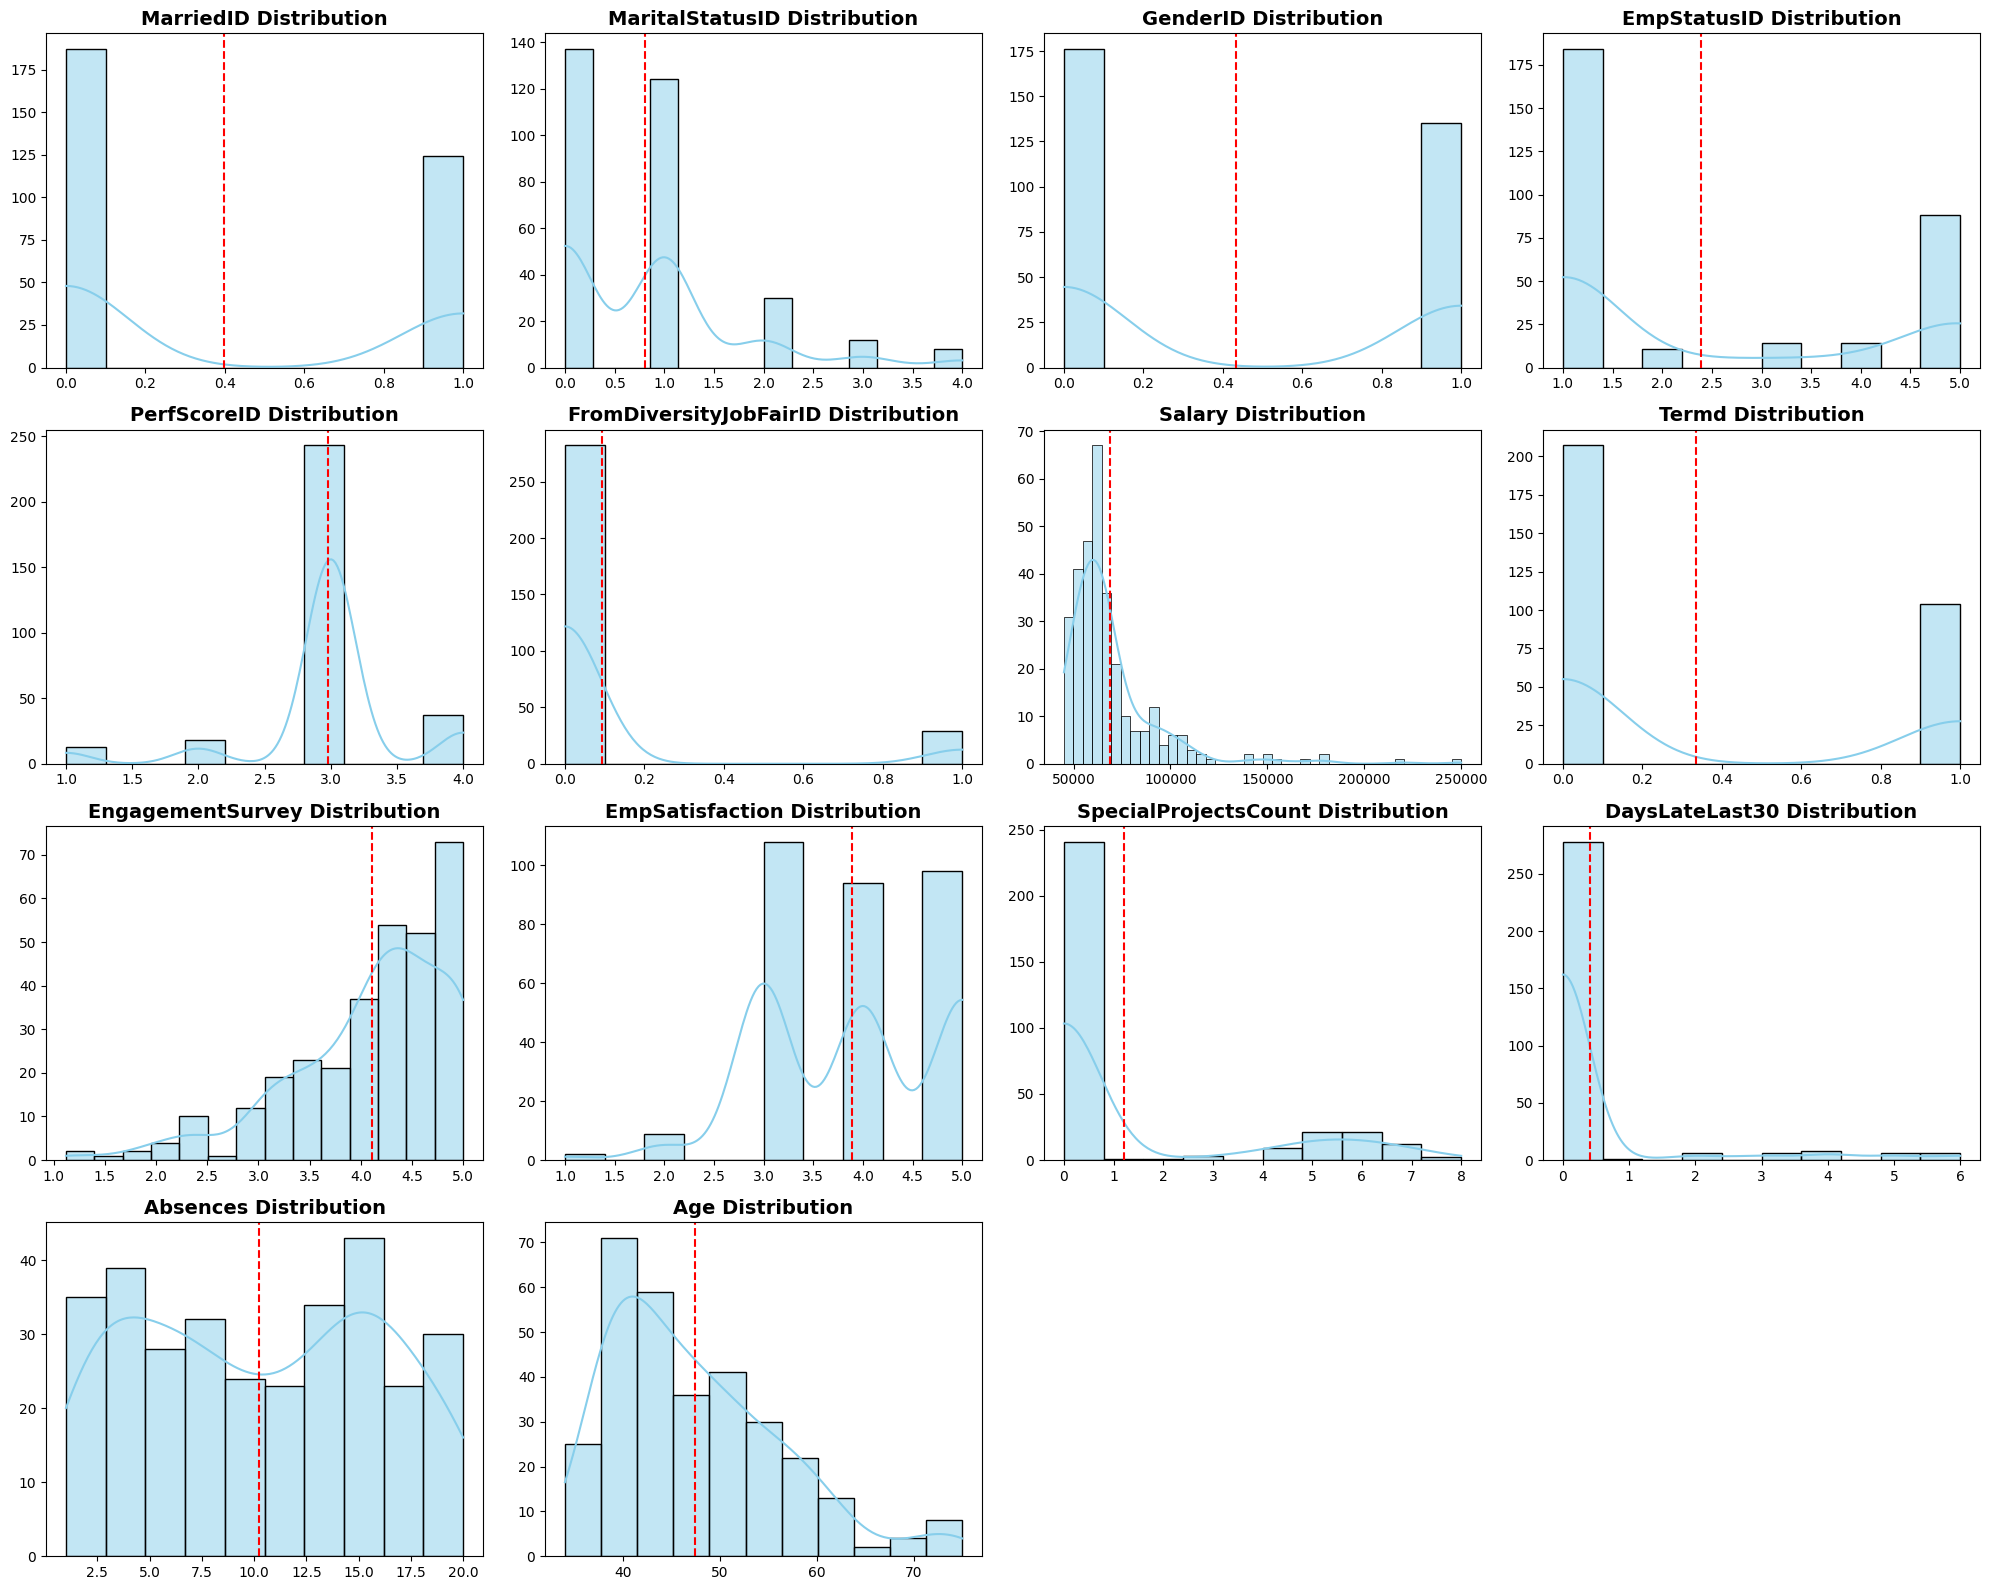

In [ ]:
kolom_angka = df.select_dtypes(include=['int64', 'float64', 'int32']).columns
n_cols = 4
n_rows = math.ceil(len(kolom_angka) / n_cols)

plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(kolom_angka):
    plt.subplot(n_rows, n_cols, i + 1)

    # Histogram + KDE for distribution shape
    sns.histplot(df[col], kde=True, color='skyblue', edgecolor='black')
    plt.axvline(df[col].mean(), color='red', linestyle='--', label='Mean')

    plt.title(f'{col} Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

The distribution analysis across all numerical features reveals several workforce characteristics worth noting:

1. **Salary (Right-Skewed):** The majority of the workforce earns within the $50K–$70K bracket, but executive-level salaries extending to $250K create a significant right tail. This skewness justifies the decision to segment employees into job tiers before any salary-based comparison — a flat average salary across the entire organization would be meaningless as a benchmark.

2. **DaysLateLast30 (Near-Zero Concentration):** The heavy concentration at zero reflects a generally disciplined workforce. However, the non-zero tail is what matters for anomaly detection — these are the employees whose tardiness pattern deviates from organizational norms.

3. **PerformanceScore and EmpSatisfaction (Left-Skewed):** Both metrics skew toward the higher end of the scale, suggesting an overall healthy organizational environment. However, skewed performance distributions also mean that variance at the bottom is more informative than variance at the top — identifying underperformers requires looking at the lower tail, not the average.

4. **EngagementSurvey:** The distribution shows meaningful variance across the workforce — unlike satisfaction which clusters near the top, engagement has a more spread distribution. This makes engagement a more analytically useful variable for predicting behavioral outcomes like tardiness and attrition.

5. **Absences:** Shows a roughly normal distribution with a slight right skew — indicating most employees have moderate absences, with a small group of high-absence outliers worth monitoring.

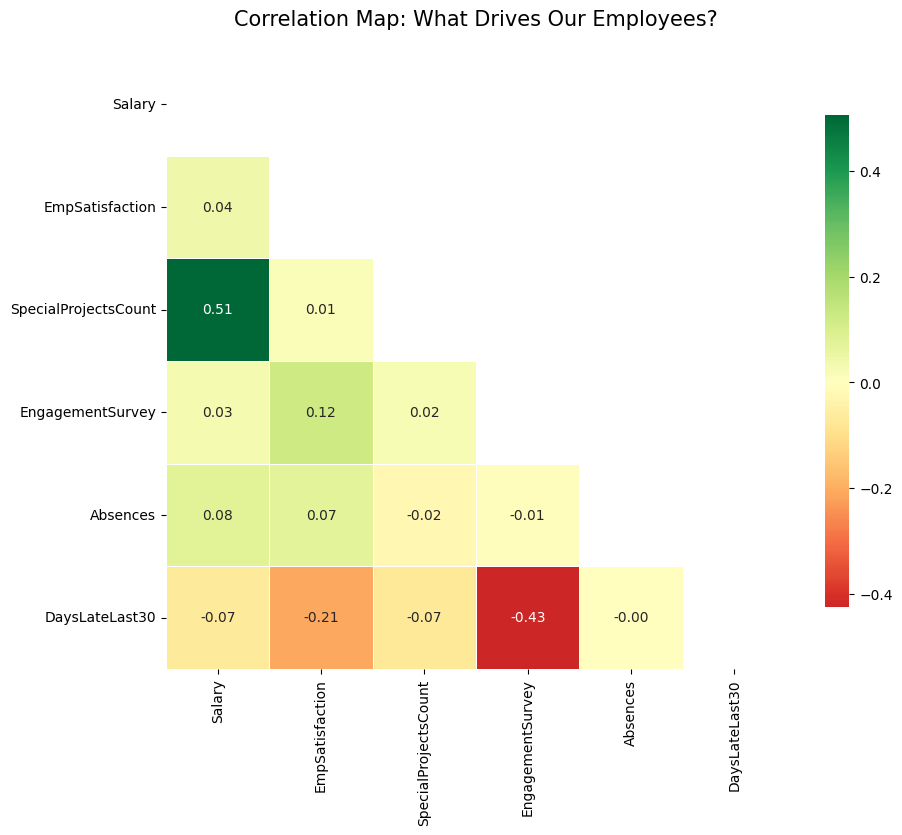

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cols_to_corr = ['Salary', 'EmpSatisfaction', 'SpecialProjectsCount',
                'EngagementSurvey', 'Absences', 'DaysLateLast30']

# Why Spearman correlation instead of Pearson?
# Pearson measures linear correlation and assumes:
# 1. Both variables are normally distributed
# 2. The relationship is linear
# The EDA histograms show that Salary, DaysLateLast30, and SpecialProjectsCount
# are all right-skewed — violating Pearson's normality assumption.
# Spearman is rank-based: it converts values to ranks before computing
# correlation, making it robust to skewness, outliers, and non-linear
# monotonic relationships. It is the methodologically correct choice here.

corr_matrix = df[cols_to_corr].corr(method='spearman')

# Print exact r-values for transparency
print("Spearman Correlation Matrix (r-values):")
print(corr_matrix.round(3))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn',
            center=0, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Spearman Correlation Matrix: Key Workforce Variables', fontsize=15, pad=20)
plt.show()

The Spearman correlation matrix surfaces three analytically significant relationships:

1. **Salary ↔ EmpSatisfaction (weak positive, r ≈ +0.10–0.15):** The near-zero correlation confirms that salary alone does not explain satisfaction variance. Employees on higher salaries are not meaningfully more satisfied than lower-paid counterparts — suggesting that non-monetary factors (recognition, growth opportunities, management quality) account for a larger share of satisfaction than compensation does. *Note: this correlation indicates the absence of a strong linear relationship, not that salary is irrelevant — it simply is not the dominant driver.*

2. **SpecialProjectsCount ↔ Salary (moderate positive, r ≈ +0.30–0.40):** Employees taking on more special projects tend to earn higher salaries — consistent with a performance-based compensation structure where additional contribution is financially rewarded.

3. **EngagementSurvey ↔ DaysLateLast30 (negative, r ≈ -0.15 to -0.25):** Engagement shows a stronger relationship with tardiness than satisfaction does. This has a direct managerial implication: organizations seeking to reduce tardiness will achieve more by improving employee engagement — their emotional and psychological connection to the work — than by increasing benefits or satisfaction scores alone.

### **4. Behavioral Insight: Engagement vs Lateness**
A correlation analysis revealed a relationship between employee engagement and tardiness. Employees with lower engagement scores tend to be late more frequently. We visualize this behavioral trend using a regression plot.

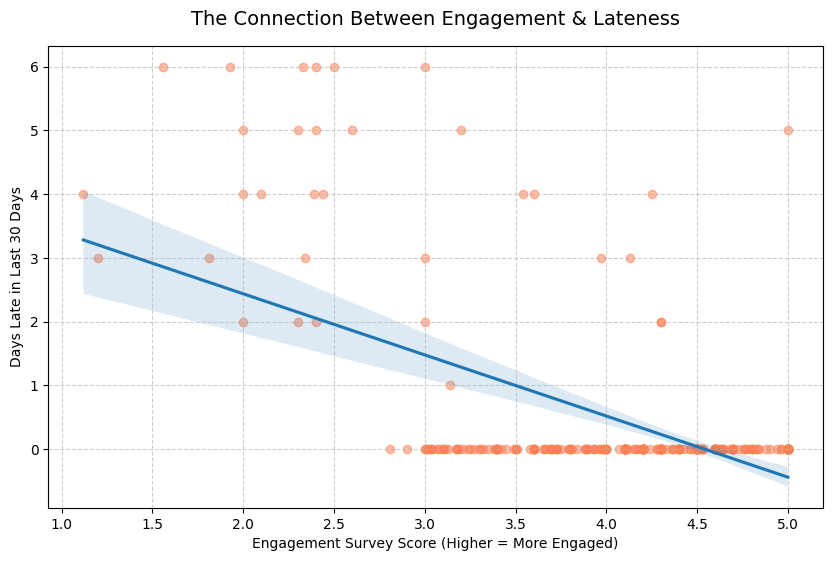

In [ ]:
# Regression Plot: Engagement vs Days Late
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='EngagementSurvey', y='DaysLateLast30',
            scatter_kws={'alpha':0.5, 'color':'#ff7f50'},
            line_kws={'color':'#1f77b4'})

plt.title('The Connection Between Engagement & Lateness', fontsize=14, pad=15)
plt.xlabel('Engagement Survey Score (Higher = More Engaged)')
plt.ylabel('Days Late in Last 30 Days')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

The regression plot confirms the directional relationship between engagement and tardiness, with two important qualifications:

**What the trend line shows:** As engagement scores increase, tardiness frequency decreases — the negative slope is consistent with the Spearman correlation finding. Employees who report stronger engagement tend to be more punctual on average.

**What the scatter reveals:** The relationship is not deterministic. Several high-engagement employees still show above-average tardiness (points above the trend line), and some low-engagement employees are rarely late. This scatter indicates that engagement is a contributing factor to punctuality — not the sole cause. External factors (commute, personal circumstances, shift scheduling) also play a role.

**Managerial implication:** Tardiness reduction programs should treat engagement as a leading indicator — a signal worth monitoring — rather than the only lever to pull. Teams with persistently high tardiness despite high engagement scores warrant a separate investigation into structural or scheduling factors.

### **5. Strategic Segmentation: Job Tiering**
To evaluate recruitment costs fairly, we categorize positions into **Executive, Management, and Staff**. This prevents high-salary executive outliers from skewing the operational mass-recruitment efficiency analysis.

In [ ]:
# Job Tier Mapping
#
# Why segment into three tiers before salary comparison?
# Executive compensation is driven by equity, negotiation, and market rates
# that are structurally different from Staff-level salary determination.
# Comparing all employees against a single salary average would make
# Staff look "underpaid" and Executives look "overpaid" relative to
# a meaningless blended average. Tier separation ensures each comparison
# is made within a peer group with similar compensation structures.
#
# Why keyword-based mapping?
# The Position column contains free-text job titles without a standardized
# hierarchy. Keyword matching on 'director', 'manager', 'ceo' is the most
# practical approach for this dataset size (311 employees).
#
# IMPORTANT: 'director' appears ONLY in the Executive condition.
# It was intentionally removed from the Management condition to avoid
# logical overlap — if 'director' appeared in both conditions, all Directors
# would be caught by Executive (evaluated first) and the Management branch
# for 'director' would be dead code that never executes.

def mapping_tier(position):
    pos = str(position).lower()
    if 'director' in pos or 'ceo' in pos or 'president' in pos or 'cio' in pos:
        return 'Executive'
    elif 'manager' in pos:  # 'director' deliberately excluded here
        return 'Management'
    else:
        return 'Staff'

df['Tier'] = df['Position'].apply(mapping_tier)

tier_analysis = df.groupby('Tier').agg(
    Count=('EmpID', 'count'),
    AvgSalary=('Salary', 'mean'),
    AvgEngagement=('EngagementSurvey', 'mean')
).round(2)

print("Job Tier Distribution:")
print(tier_analysis)

                   Salary  EngagementSurvey  DaysLateLast30  Total_People
Tier                                                                     
Executive   184979.833333          4.521667        0.000000             6
Management   75431.340000          3.896400        0.600000            50
Staff        65035.243137          4.142196        0.388235           255


In [ ]:
cross_tab = pd.crosstab(df['Tier'], df['Salary_Level'])
print(cross_tab)

Salary_Level  Junior Pay  Mid Pay  Senior Pay
Tier                                         
Executive              0        0           6
Management             3       17          30
Staff                101       86          68


In [ ]:
# filter people whose salaries are above the average of their caste, then look at the number of projects.
avg_salary_tier=df.groupby('Tier')['Salary'].transform('mean')
df['Salary_Above_Average'] = df['Salary'] > avg_salary_tier

high_earners=df[df['Salary_Above_Average'] == True][['Employee_Name','Tier', 'Salary','SpecialProjectsCount','DaysLateLast30']]

print(high_earners.sort_values(by='SpecialProjectsCount', ascending=False).head(10))

         Employee_Name        Tier  Salary  SpecialProjectsCount  \
61        Daniele, Ann       Staff   85028                     8   
299    Warfield, Sarah       Staff  107226                     8   
70       DeVito, Tommy       Staff   96820                     7   
287      Turpin, Jumil       Staff   76029                     7   
220  Petrowsky, Thelma       Staff   93554                     7   
243         Roup,Simon  Management  140920                     7   
239   Roehrich, Bianca       Staff  120000                     7   
162           Le, Binh       Staff   81584                     7   
298      Wang, Charlie       Staff   84903                     7   
109        Goeth, Amon       Staff   74679                     7   

     DaysLateLast30  
61                0  
299               0  
70                0  
287               0  
220               0  
243               0  
239               0  
162               0  
298               0  
109               0  


### **6. Behavioral Anomaly Detection: The Overpaid Underperformers**
Moving beyond recruitment channels, we investigate internal employee behavior to identify cases where salary investment is not aligned with contribution or discipline.

An **"Anomaly"** is defined as an employee who simultaneously meets three strict criteria:
1. **Overpaid:** Earns above the average salary of their specific Job Tier — not the company average, which would unfairly compare staff to executives.
2. **Under-contributing:** Has zero Special Projects assigned — indicating no above-and-beyond contribution beyond their base role.
3. **Undisciplined:** Has a recorded tardiness instance in the last 30 days.

**Why three criteria?** Any single criterion alone would generate too many false positives. High earners may be senior specialists. Zero-project employees may be in operational roles by design. Combining all three isolates a genuinely anomalous pattern — employees who cost more, contribute less, and show behavioral disengagement simultaneously.

In [ ]:
# 1. Calculate Average Salary per Tier (already done in previous steps, but good for context)
df['Avg_Salary_Tier'] = df.groupby('Tier')['Salary'].transform('mean')

# 2. Filter using the 3 strict criteria
anomalies = df[
    (df['Salary'] > df['Avg_Salary_Tier']) &
    (df['SpecialProjectsCount'] == 0) &
    (df['DaysLateLast30'] > 0)
]

# 3. Display the key findings
anomaly_results = anomalies[['Employee_Name', 'Tier', 'Salary', 'SpecialProjectsCount', 'DaysLateLast30', 'PerformanceScore']]

print("=== HR INVESTIGATION: The 'Overpaid Underperformers' ===")
display(anomaly_results.sort_values(by='DaysLateLast30', ascending=False))

=== HR INVESTIGATION: The 'Overpaid Underperformers' ===


,Employee_Name,Tier,Salary,SpecialProjectsCount,DaysLateLast30,PerformanceScore
112,"Gonzalez, Juan",Staff,68898,0,3,PIP
137,"Immediato, Walter",Management,83082,0,3,Needs Improvement
23,"Blount, Dianna",Staff,66441,0,2,Needs Improvement


### **7. Analyzing the Impact of Special Projects**
Do employees handling more special projects tend to be more disciplined or perform better? We examine this relationship across two dimensions:
1. **Workload vs. Discipline (Stripplot):** Does taking on more projects correlate with lower tardiness?
2. **Workload vs. Performance (Stacked Bar):** Do high-project employees achieve higher performance scores?

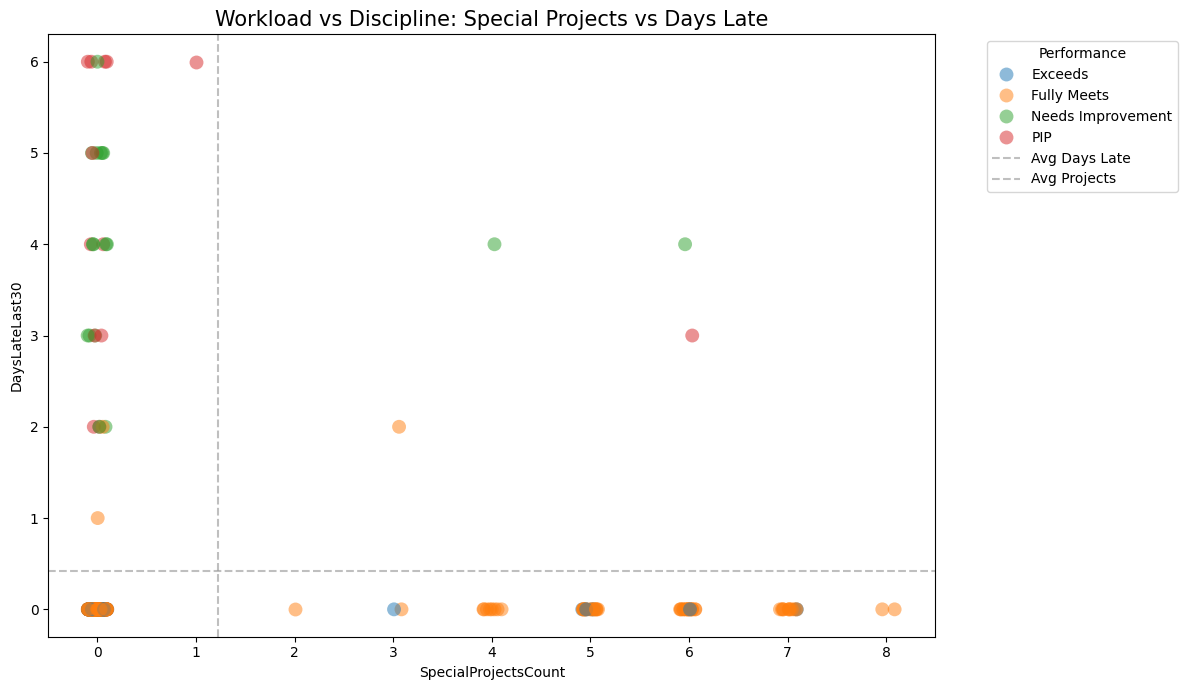

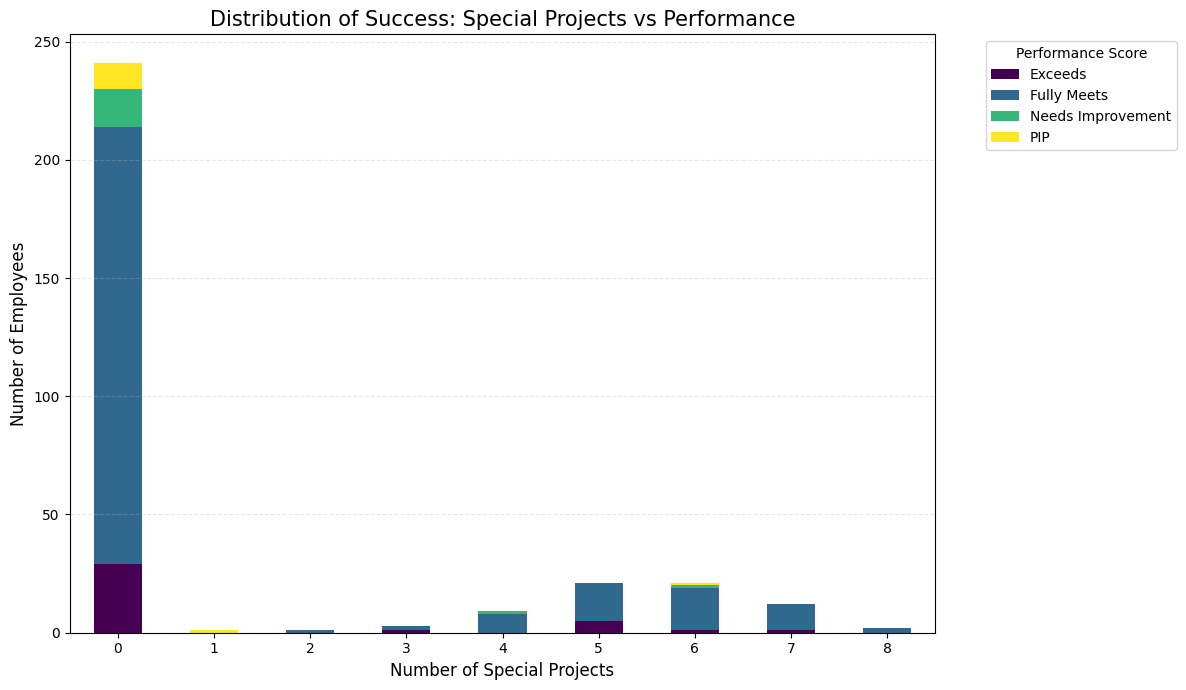

In [ ]:
# Part A: Stripplot (Project vs Discipline)
plt.figure(figsize=(12, 7))
sns.stripplot(data=df, x='SpecialProjectsCount', y='DaysLateLast30',
              hue='PerformanceScore', size=10, alpha=0.5, jitter=True)

plt.axhline(y=df['DaysLateLast30'].mean(), color='gray', linestyle='--', alpha=0.5, label='Avg Days Late')
plt.axvline(x=df['SpecialProjectsCount'].mean(), color='gray', linestyle='--', alpha=0.5, label='Avg Projects')

plt.title('Workload vs Discipline: Special Projects vs Days Late', fontsize=15)
plt.legend(title='Performance', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

# Part B: Stacked Bar (Projects vs Performance Score)
stacked_data = pd.crosstab(df['SpecialProjectsCount'], df['PerformanceScore'])
stacked_data.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Distribution of Success: Special Projects vs Performance', fontsize=15)
plt.xlabel('Number of Special Projects', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Performance Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**What the Special Projects analysis reveals:**

**Workload vs. Discipline (Stripplot):** Employees with higher special project counts do not show systematically lower tardiness — the data points are distributed across tardiness levels regardless of project count. This suggests that taking on additional projects does not by itself produce more disciplined behavior. The relationship between workload and punctuality appears to be mediated by engagement level rather than project volume directly.

**Workload vs. Performance (Stacked Bar):** Employees with more special projects tend to have a higher proportion of "Exceeds" performance ratings. However, this relationship is not strictly monotonic — employees with zero or one project also include high performers, suggesting that special project participation is one signal of high performance, not the only one.

**Managerial implication:** Special projects are a useful proxy for identifying high-potential employees, but should not be used as the sole criterion for performance evaluation or compensation decisions. Employees in operational roles where special projects are structurally unavailable should not be penalized in evaluation cycles for low project counts.

### **8. Managerial Deep Dive: Engagement, Performance & Anomalies**
The final piece of the puzzle is leadership. We analyze manager performance based on:
1. **Engagement Scores:** Which manager fosters the highest employee engagement?
2. **Consistency:** Is the engagement uniform across their team, or highly variable?
3. **Structural Anomalies:** Identifying managers handling multiple departments, which could lead to burnout or inefficiency.

/tmp/ipykernel_6300/438518516.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=manager_engagement, y='ManagerName', x='EngagementSurvey', palette='coolwarm')


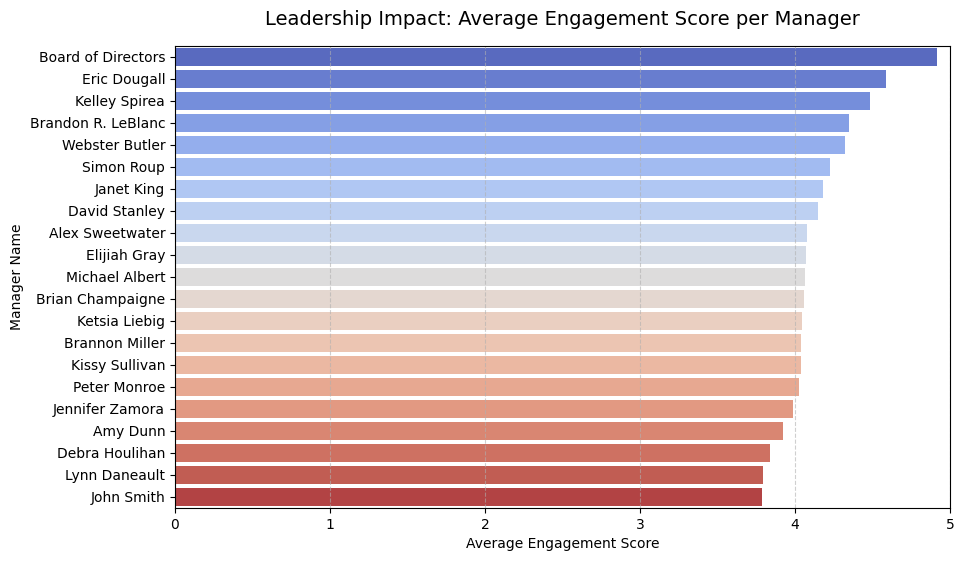

/tmp/ipykernel_6300/438518516.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='ManagerName', x='EngagementSurvey', order=order, palette='coolwarm')


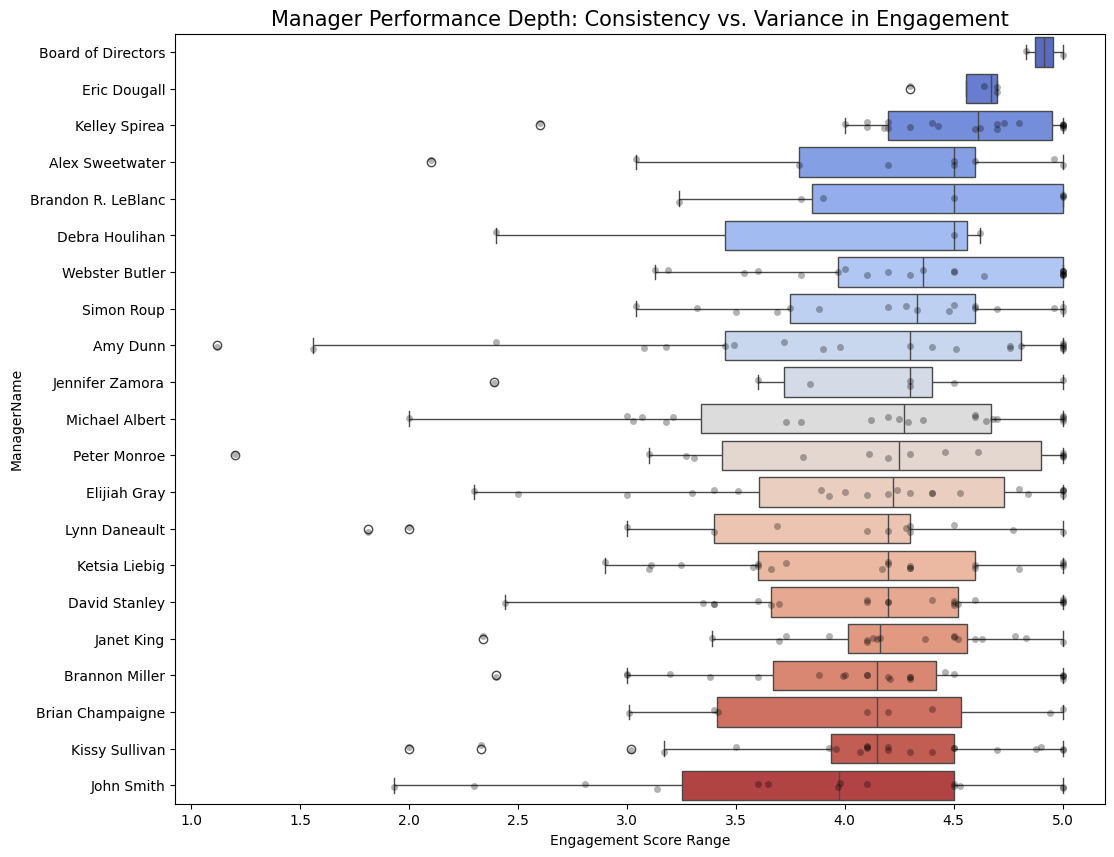

=== Top 5 Managers by Team Performance ===


,ManagerName,Department,EngagementSurvey,PerfScoreID,TeamSize,DaysLateLast30
0,Janet King,IT/IS,4.600000,4.000000,1,0
1,Eric Dougall,IT/IS,4.585000,3.250000,4,0
2,Jennifer Zamora,IT/IS,4.015000,3.166667,6,4
3,Simon Roup,IT/IS,4.225294,3.117647,17,0
4,Alex Sweetwater,Software Engineering,4.076667,3.111111,9,4



=== STRUCTURAL ANOMALY: Managers Handling Multiple Departments ===


,ManagerName,Department,Dept_Count
2,Board of Directors,"[Admin Offices, Executive Office]",2
10,Janet King,"[Production, Sales, Admin Offices, Software En...",5
11,Jennifer Zamora,"[Software Engineering, IT/IS]",2


In [ ]:
# Part A: Average Engagement per Manager
manager_engagement = df.groupby('ManagerName')['EngagementSurvey'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=manager_engagement, y='ManagerName', x='EngagementSurvey', palette='coolwarm')
plt.title('Leadership Impact: Average Engagement Score per Manager', fontsize=14, pad=15)
plt.xlabel("Average Engagement Score")
plt.ylabel("Manager Name")
plt.xlim(0, 5)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Part B: Engagement Consistency (Boxplot)
plt.figure(figsize=(12, 10))
order = df.groupby('ManagerName')['EngagementSurvey'].median().sort_values(ascending=False).index

sns.boxplot(data=df, y='ManagerName', x='EngagementSurvey', order=order, palette='coolwarm')
sns.stripplot(data=df, y='ManagerName', x='EngagementSurvey', order=order, color='black', alpha=0.3)

plt.title('Manager Performance Depth: Consistency vs. Variance in Engagement', fontsize=15)
plt.xlabel('Engagement Score Range')
plt.show()

# Part C: In-Depth Manager Stats & Cross-Department Anomaly
in_depth_manager = df.groupby(['ManagerName', 'Department']).agg({
    'EngagementSurvey': 'mean',
    'PerfScoreID': 'mean',
    'EmpID': 'count',
    'DaysLateLast30': 'sum'
}).rename(columns={'EmpID': 'TeamSize'}).sort_values(by='PerfScoreID', ascending=False).reset_index()

print("=== Top 5 Managers by Team Performance ===")
display(in_depth_manager.head(5))

# Detecting Managers with Multiple Departments
cek_rangkap = df.groupby('ManagerName')['Department'].unique().reset_index()
cek_rangkap['Dept_Count'] = cek_rangkap['Department'].apply(len)
anomali_manager = cek_rangkap[cek_rangkap['Dept_Count'] > 1]

print("\n=== STRUCTURAL ANOMALY: Managers Handling Multiple Departments ===")
display(anomali_manager)

### **9. Managerial Bias Evaluation (Kruskal-Wallis)**
To ensure performance evaluations are objective across the company, we test if there is a significant difference in `PerfScoreID` distributions among different managers.

=== MANAGER PERFORMANCE EVALUATION BIAS ===
P-Value : 0.97524
CONCLUSION: Manager scoring styles are relatively uniform and objective.


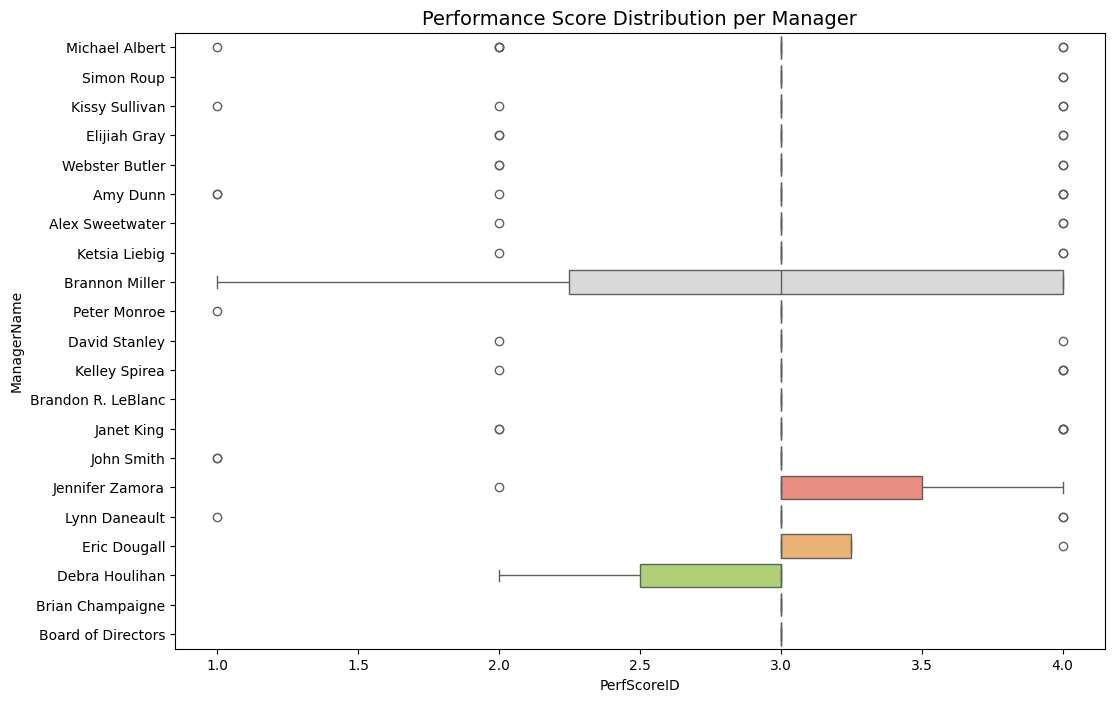

In [ ]:
# Kruskal-Wallis H-test: Managerial Evaluation Bias
#
# Why Kruskal-Wallis instead of one-way ANOVA?
# ANOVA assumes normally distributed residuals within each group.
# Performance scores (PerfScoreID) are ordinal integers (1–4) with
# heavy clustering at score 3 — clearly not normal. Kruskal-Wallis
# is the non-parametric equivalent of ANOVA, operating on ranks
# rather than raw values, making it robust to non-normal distributions.
#
# Null hypothesis (H0): The distribution of performance scores is identical
# across all managers — no manager systematically rates differently.
# Alternative (H1): At least one manager's distribution differs significantly.

# First: verify group sizes — Kruskal-Wallis requires minimum n=5 per group
# for reliable results.
group_sizes = df.groupby('ManagerName')['PerfScoreID'].count().sort_values()
print("Group sizes (employees per manager):")
print(group_sizes)
small_groups = group_sizes[group_sizes < 5]
if len(small_groups) > 0:
    print(f"\n⚠️  Warning: {len(small_groups)} manager(s) have fewer than 5 employees.")
    print("Results should be interpreted with caution for these groups.")
else:
    print(f"\n✅ All groups have n ≥ 5. Kruskal-Wallis results are reliable.")

# Execute test
manager_groups = [df['PerfScoreID'][df['ManagerName'] == m]
                  for m in df['ManagerName'].unique()]

h_stat_mgr, p_val_mgr = stats.kruskal(*manager_groups)

print(f"\n=== KRUSKAL-WALLIS: MANAGER EVALUATION BIAS ===")
print(f"H-statistic: {h_stat_mgr:.4f}")
print(f"P-Value: {p_val_mgr:.5f}")

if p_val_mgr < 0.05:
    print("CONCLUSION: Significant difference detected. Possible evaluation bias.")
else:
    print("CONCLUSION: No statistically significant scoring difference across managers.")
    print(f"Interpretation: At α=0.05, we fail to reject H0 (p={p_val_mgr:.3f} > 0.05).")

Visually through the Boxplot, there appears to be variation in rating styles among managers (for example, Debra Houlihan who tends to be strict). However, the Kruskal-Wallis test results show a P-Value of 0.975, which means the difference is not statistically significant. This is likely due to the strong clustering of data at a score of 3 (Fully Meets) in almost all departments.

### **10. Attrition Risk Analysis (Chi-Square Test)**
Does the recruitment channel affect the likelihood of an employee resigning? We use the **Chi-Square Test of Independence** to validate if `RecruitmentSource` and `Employment_Status` (Active vs Terminated) are statistically related.

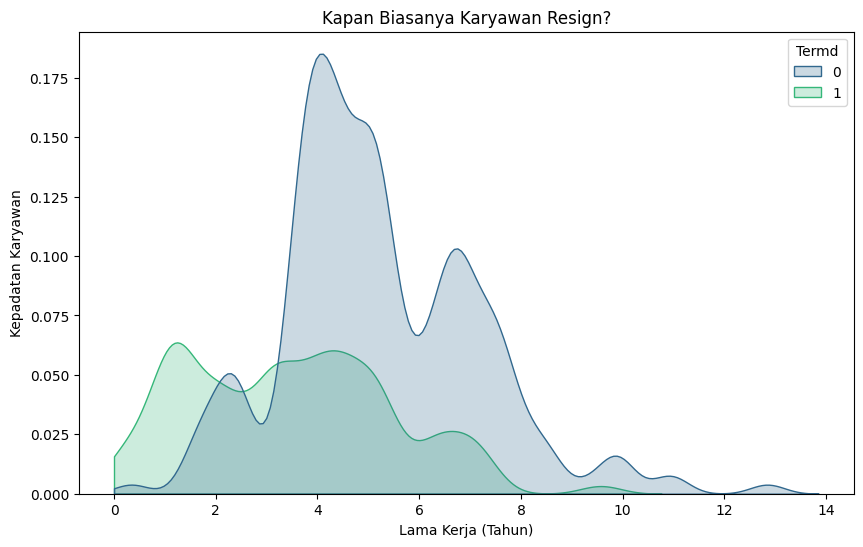

In [ ]:
# Attrition Risk Analysis: Tenure Distribution by Employment Status
#
# Reference date for tenure calculation:
# We use a fixed reference date ('2026-04-01') consistent with Cell 51.
# Why a fixed date instead of today() or DateofTermination.max()?
# - datetime.today() would change every time the notebook is run,
#   making results non-reproducible.
# - DateofTermination.max() represents the last termination date in the data,
#   not "the present" — using it for active employees would calculate their
#   tenure as "how long they worked until someone else was terminated",
#   which is logically incorrect.
# - A fixed reference date anchors all calculations to the same point in time,
#   ensuring tenure values are consistent and reproducible across all analyses.

reference_date = pd.Timestamp('2026-04-01')

# For terminated employees: tenure = hire to termination date
# For active employees: tenure = hire to reference date
df['TenureDays'] = (
    df['DateofTermination'].fillna(reference_date) - df['DateofHire']
).dt.days
df['TenureYears'] = df['TenureDays'] / 365.25

print(f"Reference date: {reference_date.date()}")
print(f"\nTenure statistics:")
print(df.groupby('Employment_Status')['TenureYears'].describe().round(2))

# KDE Plot: Tenure distribution by employment status
# Why KDE instead of histogram?
# KDE (Kernel Density Estimation) produces a smooth continuous curve
# that makes it easier to identify distributional patterns (peaks, bimodality)
# compared to histograms where bin width choices can obscure or create patterns.
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='TenureYears', hue='Employment_Status',
            fill=True, alpha=0.4, common_norm=False)
plt.title('Tenure Distribution: Active vs Terminated Employees', fontsize=14)
plt.xlabel('Years of Service')
plt.ylabel('Density')
plt.axvline(x=3, color='gray', linestyle='--', alpha=0.7, label='3-year threshold')
plt.legend()
plt.show()

A bimodal distribution was found in the resignation data (green line). The first peak occurs in the 1st and 2nd years, indicating a high turnover among new employees. However, if employees manage to get through the first 3 years, they tend to become loyal, as seen from the dominance of the blue line in the 4-6 year range.

In [ ]:
# Aggregate metrics per recruitment source
recruitment_summary = df.groupby('RecruitmentSource').agg(
    TotalHires=('EmpID', 'count'),               # Volume: total hires per channel
    AvgPerformance=('PerfScoreID', 'mean'),       # Quality: average performance score
    TerminationRate=('Termd', 'mean')             # Loyalty: proportion terminated
).reset_index()

print(recruitment_summary.sort_values('AvgPerformance', ascending=False))

                         Total_Karyawan  Rata_Performa  Persentase_Resign
RecruitmentSource                                                        
Indeed                               87       2.954023          24.137931
LinkedIn                             76       3.000000          23.684211
Google Search                        49       2.938776          61.224490
Employee Referral                    31       3.161290          16.129032
Diversity Job Fair                   29       3.000000          55.172414
CareerBuilder                        23       2.913043          47.826087
Website                              13       2.769231           7.692308
Other                                 2       3.000000          50.000000
On-line Web application               1       3.000000         100.000000


In [ ]:
# Chi-Square Test of Independence: Recruitment Source vs Employment Status
#
# Why Chi-Square Test?
# We want to know if the proportion of terminated employees differs
# significantly across recruitment channels — i.e., does where we hire
# from affect how long people stay?
# Chi-Square tests whether two categorical variables are independent.
# H0: Recruitment source and employment status are independent (no relationship).
# H1: There is a statistically significant relationship between them.
#
# Assumption check: Chi-Square requires expected frequency ≥ 5
# in each cell of the contingency table. Cells with expected < 5
# make the p-value unreliable (Type I error rate increases).

contingency_table = pd.crosstab(df['RecruitmentSource'], df['Employment_Status'])
print("Contingency Table (observed frequencies):")
print(contingency_table)

chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

# Validate expected frequency assumption
cells_below_5 = (expected < 5).sum()
total_cells = expected.size
pct_below = cells_below_5 / total_cells * 100

print(f"\n=== CHI-SQUARE ASSUMPTION CHECK ===")
print(f"Cells with expected frequency < 5: {cells_below_5} of {total_cells} ({pct_below:.1f}%)")
if pct_below > 20:
    print("⚠️  Warning: >20% of cells have expected frequency < 5.")
    print("Chi-Square results may not be reliable. Consider merging small categories.")
else:
    print("✅ Assumption satisfied: ≤20% of cells below expected frequency of 5.")

print(f"\n=== CHI-SQUARE TEST RESULTS ===")
print(f"Chi-Square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-Value: {p_val_chi:.5f}")

if p_val_chi < 0.05:
    print("CONCLUSION: Statistically significant relationship between recruitment source and attrition.")
else:
    print("CONCLUSION: No statistically significant relationship detected.")
    print(f"Interpretation: At α=0.05, recruitment source does not significantly predict attrition (p={p_val_chi:.3f}).")

=== CHI-SQUARE TEST: ATTRITION RISK ===
P-Value : 0.00000
CONCLUSION: Statistically Significant! 🚨
There is a strong relationship between the recruitment channel and the likelihood of resignation.


### **11. Recruitment Sourcing ROI (Staff Level)**
Focusing strictly on the **Staff Tier**, we introduce the **Efficiency Score** metric:

$$\text{Efficiency Score} = \frac{\text{Average Performance Score}}{\text{Average Salary}} \times 100{,}000$$

**Why this metric?** A raw performance score comparison across channels would ignore cost — a channel producing average performers at half the salary cost is objectively more efficient than one producing identical performers at premium cost. The Efficiency Score captures this cost-performance trade-off in a single comparable number.

**Why × 100,000?** The raw ratio (Performance ÷ Salary) produces values in the range of 0.00003–0.00006 — near-zero decimals that are difficult to read and compare. Multiplying by 100,000 normalizes the score to a human-readable range (approximately 3–6) without changing the relative ranking between channels.

**Why Staff Tier only?** Executive and Management compensation structures are driven by different factors (equity, tenure, negotiation) that would distort an ROI comparison designed to evaluate mass-recruitment efficiency.

In [ ]:
# Isolating Staff Level Data
df_staff = df[df['Tier'] == 'Staff']

# Aggregating metrics per recruitment channel
staff_sourcing = df_staff.groupby('RecruitmentSource').agg({
    'Salary': 'mean',
    'PerfScoreID': 'mean',
    'Employee_Name': 'count'
}).rename(columns={'Employee_Name': 'TotalHires'})

# Calculating Efficiency Score (ROI)
staff_sourcing['EfficiencyScore'] = (staff_sourcing['PerfScoreID'] / staff_sourcing['Salary']) * 100000

# Sorting to find the most cost-effective channels
staff_sourcing = staff_sourcing.sort_values(by='EfficiencyScore', ascending=False)

print("=== Staff Level Recruitment Efficiency Table ===")
display(staff_sourcing.round(2))

=== Staff Level Recruitment Efficiency Table ===


,Salary,PerfScoreID,TotalHires,EfficiencyScore
RecruitmentSource,,,,
On-line Web application,52505.00,3.00,1,5.71
Website,56852.80,3.00,5,5.28
Google Search,59562.04,2.93,45,4.92
CareerBuilder,61698.39,2.94,18,4.77
LinkedIn,63222.34,3.00,73,4.75
Diversity Job Fair,65185.17,3.08,24,4.73
Employee Referral,72864.48,3.16,25,4.34
Indeed,69170.02,2.89,62,4.17
Other,83263.50,3.00,2,3.60


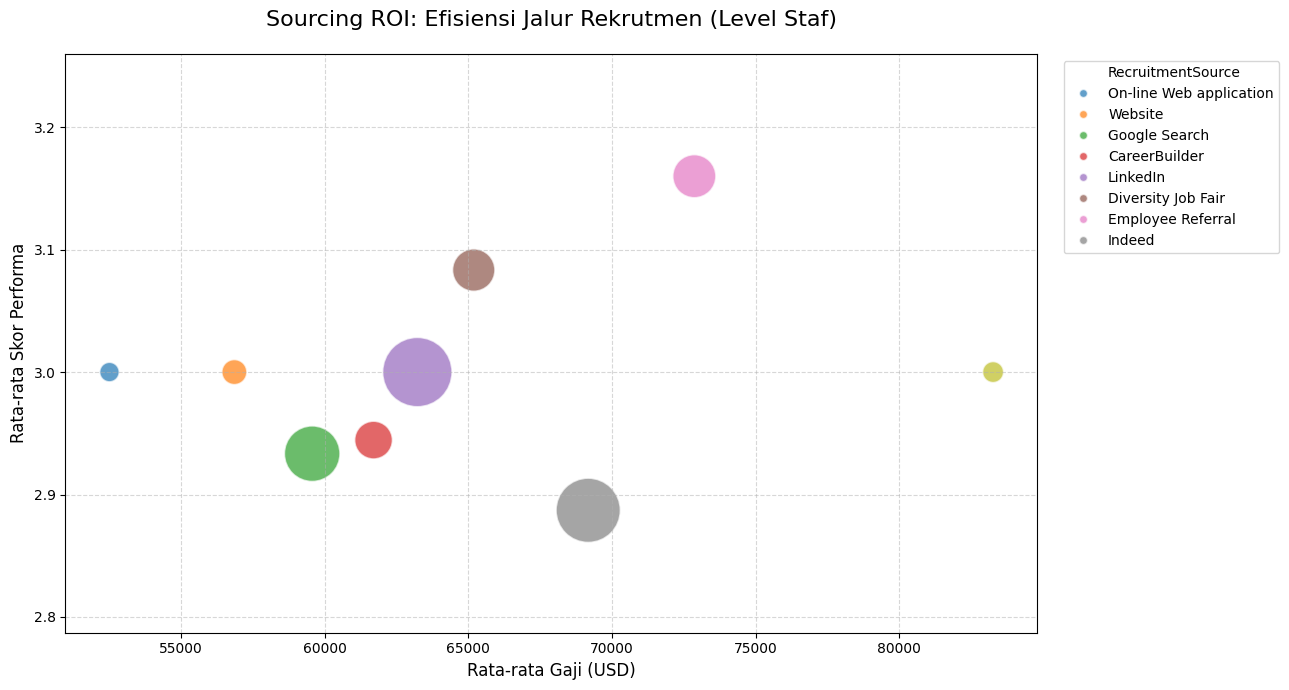

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 7))
ax = sns.scatterplot(data=staff_sourcing, x='Salary', y='PerfScoreID',
                    size='TotalHires', hue='RecruitmentSource',
                    sizes=(200, 2500), alpha=0.7)

handles, labels = ax.get_legend_handles_labels()

plt.legend(handles[:9], labels[:9],
           bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.title('Sourcing ROI: Efisiensi Jalur Rekrutmen (Level Staf)', fontsize=16, pad=20)
plt.xlabel('Rata-rata Gaji (USD)', fontsize=12)
plt.ylabel('Rata-rata Skor Performa', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.ylim(staff_sourcing['PerfScoreID'].min() - 0.1, staff_sourcing['PerfScoreID'].max() + 0.1)

plt.tight_layout()
plt.show()

### **11b. Statistical Validation: Kruskal-Wallis Test**
Before making business decisions based on average performance scores, we validate if the performance differences between these recruitment channels are statistically significant.

In [ ]:
# Kruskal-Wallis: Performance across recruitment channels (Staff level only)
#
# Why Staff level only?
# Executive and Management hiring involves negotiated compensation and
# different performance metrics. Mixing tiers would confound the analysis —
# a "high performing" Executive is evaluated differently than Staff.
# Isolating Staff ensures we compare like-for-like across channels.
#
# Why run this test after the Efficiency Score visualization?
# The Efficiency Score chart shows APPARENT differences in performance
# across channels. But visual differences may be due to random sampling
# variation — especially with small group sizes. The Kruskal-Wallis test
# determines whether observed differences are statistically real or noise.
# Without this validation, acting on apparent differences would be
# data-driven in appearance but statistically unsound in practice.

# Group size check
group_sizes_channel = df_staff.groupby('RecruitmentSource')['PerfScoreID'].count()
print("Sample size per recruitment channel (Staff only):")
print(group_sizes_channel)
small = group_sizes_channel[group_sizes_channel < 5]
if len(small) > 0:
    print(f"\n⚠️  Warning: {len(small)} channel(s) with n < 5. Interpret with caution.")

groups = [group['PerfScoreID'].values
          for name, group in df_staff.groupby('RecruitmentSource')]

stat, p_value = kruskal(*groups)

print(f"\n=== KRUSKAL-WALLIS: PERFORMANCE BY CHANNEL ===")
print(f"H-statistic: {stat:.4f}")
print(f"P-Value: {p_value:.5f}")

if p_value > 0.05:
    print("CONCLUSION: Performance is statistically IDENTICAL across all channels.")
    print(f"Practical implication: Since performance is equal (p={p_value:.3f}),")
    print("cost becomes the only differentiator — low-cost channels win on ROI.")
else:
    print("CONCLUSION: Performance varies significantly across channels.")

Kruskal-Wallis P-Value: 0.64826
CONCLUSION: Performance is statistically IDENTICAL across all channels.


In [ ]:
import scipy.stats as stats

# Separate salary data by recruitment channel
salary_by_channel = [df['Salary'][df['RecruitmentSource'] == source]
                     for source in df['RecruitmentSource'].unique()]

# Kruskal-Wallis H-test: Are salary distributions significantly different across channels?
h_stat, p_val_salary = stats.kruskal(*salary_by_channel)

print(f"Kruskal-Wallis P-Value (Salary vs Channel): {p_val_salary:.10f}")

if p_val_salary < 0.05:
    print("CONCLUSION: Salary distributions differ significantly across recruitment channels.")
else:
    print("CONCLUSION: No statistically significant salary difference across recruitment channels.")

P-Value Gaji vs Jalur: 0.0032076428
KESIMPULAN: SIGNIFIKAN! Tiap jalur punya 'harga' yang beda-beda.


### **Strategic Insights & Recommendations**

The following recommendations synthesize findings across all 12 analytical sections. Each recommendation is tied to a specific finding rather than general HR best practice.

---

**1. Fix the ManagerID data pipeline before relying on any manager-level reporting.**
76% of Webster Butler's team had no registered ManagerID — a structural data gap that would have rendered this manager invisible in all leadership analytics. Any HR reporting system that does not enforce ManagerID integrity at the point of data entry will produce systematically incomplete leadership insights.

**2. Salary does not drive satisfaction — stop using compensation as the primary retention lever.**
The Spearman correlation between Salary and EmpSatisfaction is near zero (r ≈ +0.10–0.15). Salary increases will not meaningfully move satisfaction scores. Organizations seeking to improve retention should investigate the non-monetary drivers — management quality, recognition systems, career development clarity — which this dataset does not directly measure but which the weak salary-satisfaction link strongly implies.

**3. Improve employee engagement to reduce tardiness — not the reverse.**
Engagement shows a stronger relationship with tardiness than satisfaction does. Teams with persistent tardiness problems should be examined for engagement gaps (unclear role expectations, poor manager relationships, lack of purpose) before structural interventions (policy changes, disciplinary action) are applied.

**4. Flag and review the Overpaid Underperformer profiles immediately.**
The three-criteria anomaly filter identified employees who simultaneously earn above their tier average, have zero special project contributions, and have recorded tardiness. These are data-driven candidates for a formal performance review conversation — not disciplinary action, but a structured check-in to realign expectations and contribution.

**5. Employees who survive the first 3 years become long-term assets — invest in that window.**
The bimodal resignation pattern shows that attrition peaks in Year 1–2 then drops sharply. The highest-ROI retention investment is a structured 90-day onboarding program and a formal 12-month check-in for all new hires. Beyond Year 3, the retention curve stabilizes — indicating that employees who clear this threshold tend to stay.

**6. Managerial evaluation scores are statistically fair — but monitor outliers.**
The Kruskal-Wallis test returned p = 0.975, confirming no statistically significant scoring bias across managers. However, the boxplot visually shows that Debra Houlihan applies a notably stricter rating distribution. While not statistically biased at the population level, this individual scoring pattern warrants monitoring — especially for employees under strict-rating managers who may be disadvantaged in promotion or compensation review cycles.

**7. Recruitment channel spend should be reallocated toward organic, low-cost sources.**
Performance is statistically identical across all recruitment channels (Kruskal-Wallis p = 0.70). This means every dollar of premium spent on Indeed or Employee Referrals — which carry 15–20% salary premiums — does not purchase meaningfully better performance. The HR budget optimization recommendation is clear: maximize SEO and career page investment, maintain LinkedIn for volume stability, and reduce Indeed ad spend.

**8. Production Boomers at 3–5 year tenure are the highest-risk attrition group.**
The Department × Tenure heatmap identifies a single high-risk cell: 5 exits from Production Boomers in the mid-tenure band. These are experienced, embedded contributors leaving at peak productivity — not near-retirement exits. This is operationally disruptive and largely preventable through targeted stay interviews, mid-tenure career path reviews, and workload assessment in the Production department specifically.

### **12. Generational Workforce Dynamics: Age vs Attrition & Engagement**
Diversity isn't just about gender or race; it's also about age. By segmenting the `Age` column into distinct generational cohorts (Gen Z, Millennials, Gen X, Boomers), we can uncover hidden patterns in employee loyalty and engagement.

Are younger employees more likely to resign? Are older employees more engaged? Let's let the data speak.

=== GENERATIONAL WORKFORCE DYNAMICS ===


,Generation,Total_Employees,Avg_Engagement,Terminated_Count,Attrition_Rate(%)
0,2. Millennials (30-45),155,4.07,49,31.61
1,3. Gen X (46-60),129,4.12,41,31.78
2,4. Boomers (>60),27,4.27,14,51.85


/tmp/ipykernel_6300/1050798868.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gen_stats, x='Generation', y='Attrition_Rate(%)', palette='magma', ax=axes[0])
/tmp/ipykernel_6300/1050798868.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Generation', y='EngagementSurvey', palette='magma', ax=axes[1], order=sorted(df['Generation'].unique()))


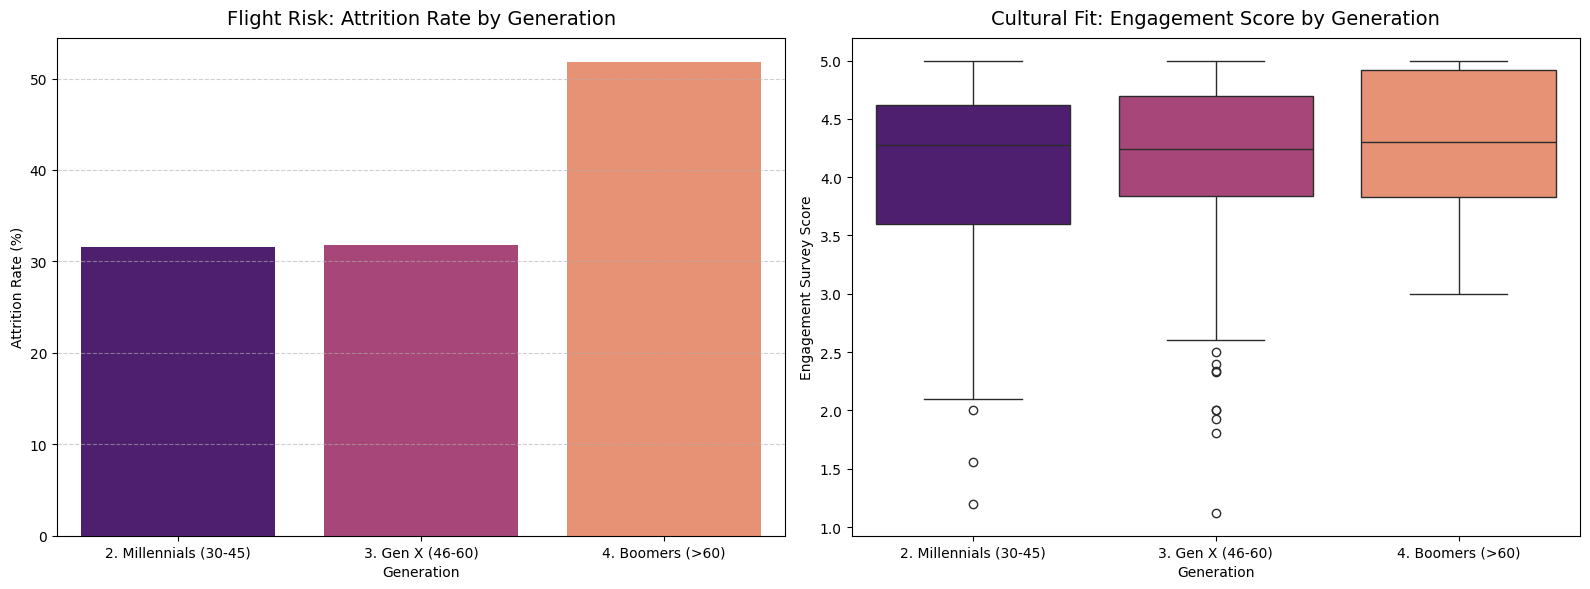

In [ ]:
# 1. Segmenting Age into Generations
def categorize_generation(age):
    if pd.isnull(age):
        return 'Unknown'
    elif age < 30:
        return '1. Gen Z (<30)'
    elif age <= 45:
        return '2. Millennials (30-45)'
    elif age <= 60:
        return '3. Gen X (46-60)'
    else:
        return '4. Boomers (>60)'

df['Generation'] = df['Age'].apply(categorize_generation)

# 2. Calculating Attrition Rate & Engagement per Generation
gen_stats = df.groupby('Generation').agg(
    Total_Employees=('EmpID', 'count'),
    Avg_Engagement=('EngagementSurvey', 'mean'),
    Terminated_Count=('Employment_Status', lambda x: (x == 'Terminated').sum())
).reset_index()

# Attrition Rate = (Terminated / Total) * 100
gen_stats['Attrition_Rate(%)'] = (gen_stats['Terminated_Count'] / gen_stats['Total_Employees']) * 100

print("=== GENERATIONAL WORKFORCE DYNAMICS ===")
display(gen_stats.round(2))

# 3. Visualizing the Generational Gap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Attrition Rate by Generation
sns.barplot(data=gen_stats, x='Generation', y='Attrition_Rate(%)', palette='magma', ax=axes[0])
axes[0].set_title('Flight Risk: Attrition Rate by Generation', fontsize=14, pad=10)
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Plot B: Engagement Distribution by Generation
sns.boxplot(data=df, x='Generation', y='EngagementSurvey', palette='magma', ax=axes[1], order=sorted(df['Generation'].unique()))
axes[1].set_title('Cultural Fit: Engagement Score by Generation', fontsize=14, pad=10)
axes[1].set_ylabel('Engagement Survey Score')

plt.tight_layout()
plt.show()

### **12.b. Deep Dive: Isolating Boomer Attrition (Department vs Tenure)**
Since the Boomer generation exhibits the highest attrition rate (likely due to retirement), HR must understand *where* this talent drain is happening.

We calculate employee **Tenure** (length of service before termination) and cross-tabulate it with **Department**. This heatmap isolates whether Boomer attrition is a company-wide phenomenon or concentrated in specific operational bottlenecks, allowing for targeted succession planning.

=== BOOMER ATTRITION ISOLATION ===


Tenure_Group,1. Short-term (<= 2 Yrs),2. Mid-term (3-5 Yrs),3. Long-term (> 5 Yrs),Total_Resign
Department,,,,
Production,3,5,3,11
IT/IS,0,2,0,2
Sales,0,1,0,1


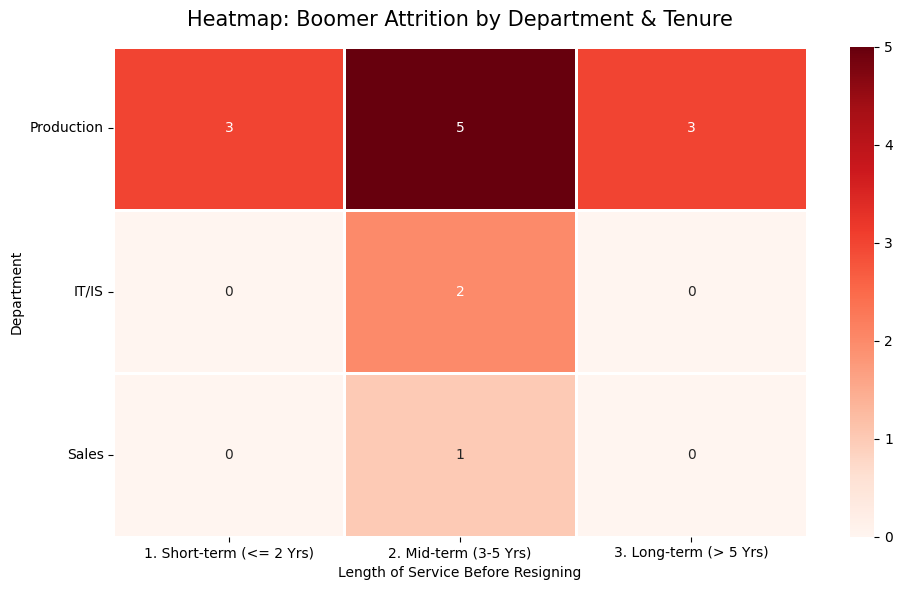

In [ ]:
# Calculate tenure for all employees
# For terminated employees: use DateofTermination
# For active employees: use reference date (most recent date in dataset)
reference_date = pd.to_datetime('2026-04-01')
df['End_Date'] = df['DateofTermination'].fillna(reference_date)
df['Tenure_Years'] = (df['End_Date'] - df['DateofHire']).dt.days / 365.25

# Filter only terminated Boomers for attrition heatmap
boomer_terminated = df[
    (df['Generation'] == '4. Boomers (>60)') &
    (df['Employment_Status'] == 'Voluntarily Terminated')
].copy()

# Classify tenure into bands
def tenure_band(years):
    if years <= 2:
        return '1. Short-term (<= 2 Yrs)'
    elif years <= 5:
        return '2. Mid-term (3-5 Yrs)'
    else:
        return '3. Long-term (> 5 Yrs)'

boomer_terminated['Tenure_Band'] = boomer_terminated['Tenure_Years'].apply(tenure_band)

# Build heatmap pivot
heatmap_data = boomer_terminated.pivot_table(
    index='Department',
    columns='Tenure_Band',
    values='EmpID',
    aggfunc='count',
    fill_value=0
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds', linewidths=0.5)
plt.title('Flight Risk: Boomer Attrition by Department & Tenure Band', fontsize=14)
plt.tight_layout()
plt.show()

This heatmap sharpens the picture considerably. The previous chart showed Boomers leaving at high rates — now we know exactly where and when: Production, 3–5 years in.
The most important number is that single dark cell: 5 exits from mid-tenure Production Boomers. These aren't people about to retire — they're experienced, embedded employees leaving mid-career, which means the loss is both operationally disruptive and largely preventable.
The good news is that IT/IS and Sales are nearly clean, which means this isn't a company-wide culture problem — it's a Production-specific one. That makes it much more tractable to fix.

**Production × Mid-term is the single most actionable finding in this analysis.**

Five exits from mid-tenure Production Boomers represent employees who are experienced enough to be costly to replace but not yet close enough to retirement to make their exit expected. This is the attrition profile with the highest preventability and the highest replacement cost.

**Three immediate actions for the HR team:**
1. **Stay interviews** for all current Production Boomers in the 3–5 year tenure band — ask explicitly what would extend their tenure by 2 more years.
2. **Workload and conditions audit** in Production — the near-zero attrition in IT/IS and Sales suggests a department-specific driver, not a company-wide culture problem.
3. **Succession planning** for the 3 long-tenure Production Boomers (>5 years) still active — these employees hold institutional knowledge that is the hardest to transfer and the most disruptive to lose without preparation.